# Velocity Estimation In Aorta

## Method Number 1: TAFE in CTP
## Method Number 2: ADFE in CTP
## Method Number 3: Bolus transit time estimation


### Pipeline
 - Extracting descending aorta
 - Projecting attenuation on the mesh
 - Interpolation on the centreline array
 - Implementing method number 1 using the inlet curve and centreline arrays
 - Implementing method number 2 using FEniCs
 - Implementing method number 3 using dt estimation 

In [1]:
import vtk
import numpy as np
import glob
import os
import sys
import glob
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.linalg import toeplitz
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk
from sklearn.linear_model import OrthogonalMatchingPursuit

sys.path.append(os.path.pardir)
from old.utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile, ReadVTKFile


### Reading Centerline

In [2]:
def pth_to_points(PathFile):
    with open(PathFile, "r") as path:
        tree = ET.parse(path)
    root = tree.getroot()

    # Extract points
    points = []
    for path_point in root.findall(".//path_point/pos"):
        x = float(path_point.attrib['x'])
        y = float(path_point.attrib['y'])
        z = float(path_point.attrib['z'])
        points.append([x, y, z])
    
    direction = []
    for tangent in root.findall(".//path_point/tangent"):
        x = float(tangent.attrib['x'])
        y = float(tangent.attrib['y'])
        z = float(tangent.attrib['z'])
        direction.append([x, y, z])

    return points, direction

def points_to_vtp(points):
    # Create VTK points
    vtk_points = vtk.vtkPoints()
    for point in points:
        vtk_points.InsertNextPoint(point)

    # Create a polyline
    polyline = vtk.vtkPolyLine()
    polyline.GetPointIds().SetNumberOfIds(len(points))
    for i in range(len(points)):
        polyline.GetPointIds().SetId(i, i)

    # Create a cell array to store the polyline
    cells = vtk.vtkCellArray()
    cells.InsertNextCell(polyline)

    # Create a polydata object
    polydata = vtk.vtkPolyData()
    polydata.SetPoints(vtk_points)
    polydata.SetLines(cells)

    return polydata

In [3]:
centreline_path = "/Volumes/T7_Research/CABG/06_ContrastDispersion/2_SimVascularProjects/VA02B/Paths/aorta_d.pth"
points, directions = np.array(pth_to_points(centreline_path))

In [4]:
points.shape

(106, 3)

In [5]:
points_decimated = points[::10,:]
directions_decimated = directions[::10,:]
points_decimated.shape

(11, 3)

### Reading mesh file

In [6]:
path = "/Volumes/T7_Research/CABG/06_ContrastDispersion/2_SimVascularProjects/VA02B/Meshes"
filename = "aorta_d.vtu"

Aorta = ReadVTUFile(os.path.join(path, filename))

In [7]:
image_path = "/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP"
image_names = np.sort(np.array(glob.glob(os.path.join(image_path,"*.vtk"))))
image_names

array(['/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_01.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_02.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_03.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_04.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_05.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_06.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_07.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_08.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_09.vtk',
       '/Volumes/T7_Research/CABG/06_ContrastDispersion/1_CTPImages/VA02B/CTP/VA02B_10.vtk'],
      dtype='<U82')

In [8]:
ReadImages = np.vectorize(ReadVTKFile)

In [9]:
Images = ReadImages(image_names)

In [10]:
def ProjectImageToMesh(image, mesh):
    ProbeFilter = vtk.vtkProbeFilter()
    ProbeFilter.SetInputData(mesh)
    ProbeFilter.SetSourceData(image)
    ProbeFilter.Update()
    return ProbeFilter.GetOutput()

In [11]:
Projection = np.vectorize(ProjectImageToMesh)
ProjectedMeshes = Projection(Images, Aorta)


In [12]:
ProjectedMeshes

array([<UnstructuredGrid(0x167662ef0) at 0x168e5af80>,
       <UnstructuredGrid(0x1676647d0) at 0x168e5a6e0>,
       <UnstructuredGrid(0x167665810) at 0x168e5b3a0>,
       <UnstructuredGrid(0x167653d60) at 0x168e5b7c0>,
       <UnstructuredGrid(0x167667660) at 0x168e5b820>,
       <UnstructuredGrid(0x13795ddd0) at 0x168e5b880>,
       <UnstructuredGrid(0x168d2e710) at 0x168e5b8e0>,
       <UnstructuredGrid(0x168d21a90) at 0x168e5b940>,
       <UnstructuredGrid(0x168d30740) at 0x168e5b9a0>,
       <UnstructuredGrid(0x137b5a8f0) at 0x168e5ba00>], dtype=object)

In [13]:
def GetScalarArrayName(Data):
    for i in range(Data.GetPointData().GetNumberOfArrays()):
        array_name_ = Data.GetPointData().GetArrayName(i)
        if 'scalar' in array_name_.lower():
            return array_name_

def GetArray(VTUVolume):
    ScalaraArrayName = GetScalarArrayName(VTUVolume)
    MBF_array = vtk_to_numpy(VTUVolume.GetPointData().GetArray(ScalaraArrayName))
    return MBF_array


def SphereClipMean(mesh, radius, centre):
    sphere = vtk.vtkSphere()
    sphere.SetCenter(centre)
    sphere.SetRadius(radius)

    clipper = vtk.vtkClipDataSet()
    clipper.SetInputData(mesh)
    clipper.SetClipFunction(sphere)
    clipper.InsideOutOn()
    clipper.GetOutputInformation(1)
    clipper.Update()

    scalar_array = GetArray(clipper.GetOutput())
    return np.mean(scalar_array)


def ClipVolumeWPlane(volume, center, normal, IO = False):
    plane = vtk.vtkPlane()
    plane.SetOrigin(center)
    plane.SetNormal(normal)

    clipper = vtk.vtkClipDataSet()
    clipper.SetInputData(volume)
    clipper.SetClipFunction(plane)
    if IO:
        clipper.InsideOutOn()
    else:
        clipper.InsideOutOff()

    clipper.Update()

    return clipper.GetOutput()


def SliceWPlane(Volume,Origin,Norm):
    plane=vtk.vtkPlane()
    plane.SetOrigin(Origin)
    plane.SetNormal(Norm)
    Slice=vtk.vtkCutter()
    Slice.GenerateTrianglesOff()
    Slice.SetCutFunction(plane)
    Slice.SetInputData(Volume)
    Slice.Update()
    
    return Slice.GetOutput()

def GetRadius(plane):
    surface_filter = vtk.vtkDataSetSurfaceFilter()
    surface_filter.SetInputData(plane)
    surface_filter.Update()
    polydata = surface_filter.GetOutput()

    triangulator = vtk.vtkTriangleFilter()
    triangulator.SetInputData(polydata)
    triangulator.Update()

    mass = vtk.vtkMassProperties()
    mass.SetInputConnection(triangulator.GetOutputPort())
    mass.Update()

    SurfaceArea = mass.GetSurfaceArea()
    radius = np.sqrt(SurfaceArea/np.pi)
    return radius



In [14]:
plane_inlet = ClipVolumeWPlane(ProjectedMeshes[0], points_decimated[0], directions_decimated[0])
radius = GetRadius(plane_inlet)

radius

np.float64(54.72694025958241)

In [15]:
array_ = SphereClipMean(ProjectedMeshes[0], radius/10, points_decimated[0])
array_
points_decimated

array([[  37.1015625 ,  -99.1015625 , -185.5       ],
       [  37.79294544,  -98.67643097, -192.74002188],
       [  39.83065442,  -98.01873948, -206.55771213],
       [  41.7890625 ,  -97.9296875 , -220.5       ],
       [  41.85275768,  -99.29620157, -233.58037202],
       [  42.0364479 , -103.73927828, -244.8827627 ],
       [  41.7890625 , -110.4296875 , -254.5       ],
       [  38.28570836, -116.82050673, -263.34814942],
       [  33.66919946, -123.92317027, -271.46763235],
       [  29.2890625 , -131.1328125 , -279.5       ],
       [  25.31729831, -135.58614723, -287.10853468]])

In [16]:
Array = np.zeros((points_decimated.shape[0], ProjectedMeshes.size))


Array.shape

(11, 10)

In [17]:

for i, mesh in enumerate(ProjectedMeshes):
    for j, point in enumerate(points_decimated):

        Array[j, i] = SphereClipMean(mesh, radius/10, point)



Array.shape

/Users/anaseresti/miniconda3/envs/Perfusion/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/anaseresti/miniconda3/envs/Perfusion/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(11, 10)

(10, 10)


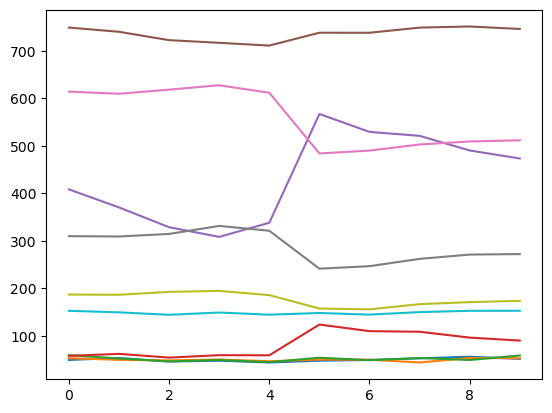

In [18]:
Array = Array[:-1, :]

print(Array.shape)

plt.plot(Array)
plt.show()


In [19]:
Array.shape


(10, 10)

In [20]:
index = 5

array_sup, array_inf = np.vsplit(Array, [index])

array_sup.shape

(5, 10)

In [21]:
array_inf.shape

(5, 10)

In [22]:
t = np.linspace(0, Array.shape[1]*2-1, num = Array.shape[1]*2)

In [23]:
t

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19.])

In [24]:
t_old_inf = t[::2]

In [25]:
t_old_inf

array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18.])

In [26]:
t_old_sup = t[1::2]

In [27]:
t_old_sup

array([ 1.,  3.,  5.,  7.,  9., 11., 13., 15., 17., 19.])

In [28]:
f_inf = interp1d(t_old_sup, array_inf, kind='cubic', fill_value="extrapolate")
array_inf_new = f_inf(t)
array_inf_new.shape

(5, 20)

In [29]:
f_sup = interp1d(t_old_inf, array_sup, kind='cubic', fill_value="extrapolate")
array_sup_new = f_sup(t)


In [30]:
Array_new = np.vstack([array_inf_new, array_sup_new])

In [31]:
Array_new.shape

(10, 20)

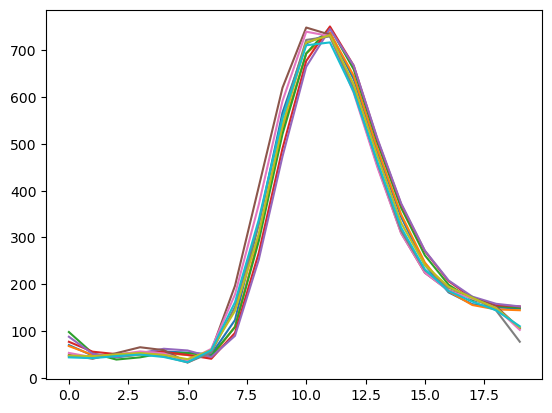

In [32]:
plt.plot(Array_new.T)
plt.show()

### Velocity Estimation (TAFE)

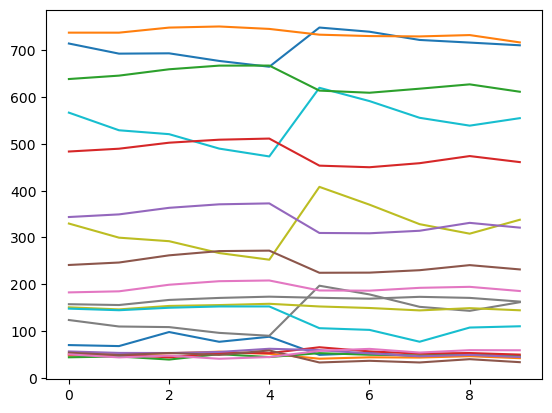

In [33]:
plt.plot(Array_new)
plt.show()

In [34]:
idx = np.argmax(Array_new, axis=1)
idx

array([11, 11, 11, 11, 11, 10, 10, 11, 11, 11])

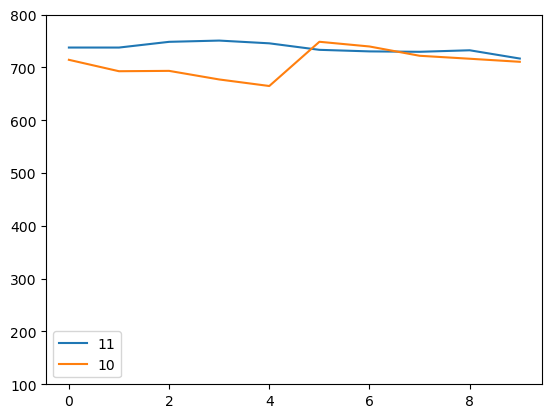

In [35]:
plt.plot(Array_new[:,11], label="11")
plt.plot(Array_new[:,10], label='10')
plt.ylim((100, 800))
plt.legend()
plt.show()

In [36]:
x = np.linspace(0, Array_new.shape[0]-1, num = Array_new.shape[0])
x

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [37]:
temporal = Array_new[0, :]
spatial = Array_new[:, 11]

upslope = temporal[7:10]
t_upslope = t[7:10]

t_upslope


array([7., 8., 9.])

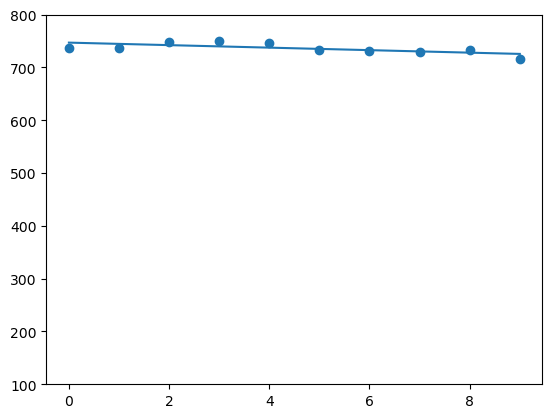

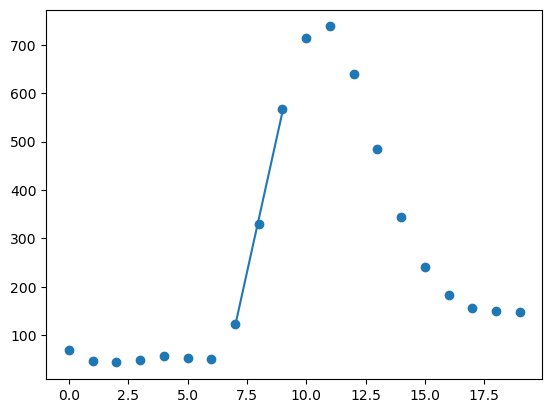

In [38]:
slope_t, intercept_t,_,_,_ = linregress(t_upslope, upslope)
slope_x, intercept_x,_,_,_ = linregress(x, spatial)

plt.plot(x, slope_x*x + intercept_x)
plt.scatter(x, spatial)
plt.ylim(100, 800)
plt.show()

plt.plot(t_upslope, slope_t*t_upslope + intercept_t)
plt.scatter(t, temporal)
plt.show()

In [39]:
# Cum dist

dist = np.cumsum(np.sqrt(np.sum((points[1:,:] - points[0:-1,:])**2, axis=1)))/10 #cm

In [40]:
dist.shape
print(points_decimated.shape)
dist_decimated = dist[::10]
dist_decimated.shape

(11, 3)


(11,)

In [41]:
slope_x, intercept_x,_,_,_ = linregress(dist_decimated[:-1], spatial)
slope_x

np.float64(-1.9051400667014706)

In [42]:
heartrate = 96 #beats/min
interval = 2*(60/heartrate)
interval * t

array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.  ,
       11.25, 12.5 , 13.75, 15.  , 16.25, 17.5 , 18.75, 20.  , 21.25,
       22.5 , 23.75])

In [43]:
print(slope_t)
t_upslope = t[7:10] * interval
slope_t, intercept_t,_,_,_ = linregress(t_upslope, upslope)
print(slope_t)

221.59573587249014
177.27658869799214


In [44]:
velocity_estimated = slope_t/slope_x
velocity_estimated

np.float64(-93.05173503852976)

### Bolus arrival time

0.0
23.75


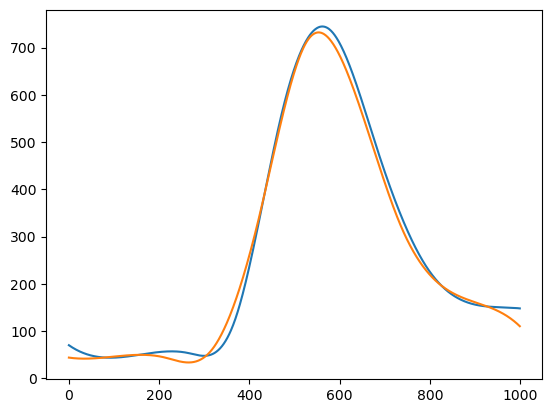

In [45]:
time_old = t*interval
print(time_old.min())
print(time_old.max())
time_new = np.linspace(time_old.min(), time_old.max(), num = 1000)

inlet = Array_new[0,:]
outlet = Array_new[-1,:]


f1 = interp1d(time_old, inlet, kind='cubic')
inlet_interp = f1(time_new)

f2 = interp1d(time_old, outlet, kind='cubic')
outlet_interp = f2(time_new)

plt.plot(inlet_interp)
plt.plot(outlet_interp)
plt.show()

In [46]:
inlet_toeplitz = toeplitz(inlet_interp, np.zeros(len(inlet_interp)))


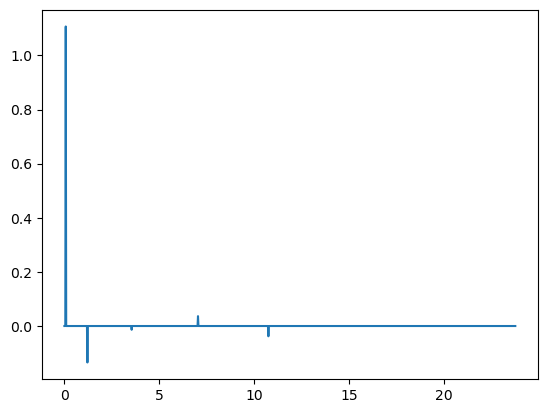

In [47]:
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=5)
omp.fit(inlet_toeplitz, outlet_interp)
x_sol = omp.coef_
plt.plot(time_new, x_sol)
plt.show()

In [48]:
delay_idx = np.argmax(x_sol)
delay = time_new[delay_idx]
v_estimated = dist[-1]/delay

print(delay)
print(v_estimated)

0.07132132132132132
166.4985659044134
